# Fitting the Crab Spectrum with the Neural-Network Response and Background Approximation

## Introduction

This notebook demonstrates an unbinned spectral analysis of the Crab Nebula using a simulated power-law spectrum. 

> **Note on Underlying Mechanics:** To keep this tutorial concise, the detailed explanations of the underlying classes (such as `NFResponse`, `NFBackground`, and `UnbinnedThreeMLPointSourceResponseIRFAdaptive`) have been omitted here. If you are unfamiliar with the Neural-Network Response, the Background Approximation, or the corresponding hardware requirements introduced for DC4, **please refer to the foundational tutorial:** `example_grb_fit_normalizing_flows.ipynb`.

## Example

### Basic Setup

In [1]:
from pathlib import Path
from cosipy.util import fetch_wasabi_file
from cosipy.spacecraftfile import SpacecraftHistory
from astropy.time import Time

import astropy.units as u
from copy import deepcopy
import matplotlib.pyplot as plt
import numpy as np

from threeML import PointSource, Model, JointLikelihood, DataList
from astromodels import Parameter, Powerlaw

from cosipy.threeml.unbinned_model_folding import CachedUnbinnedThreeMLModelFolding
from cosipy.statistics import UnbinnedLikelihood
from cosipy.interfaces import ThreeMLPluginInterface
from cosipy.interfaces.expectation_interface import SumExpectationDensity

from cosipy.event_selection.time_selection import TimeSelector
from cosipy.data_io.EmCDSUnbinnedData import TimeTagEmCDSEventDataInSCFrameFromDC3Fits

from cosipy.response.ml.NFResponse import NFResponse
from cosipy.response.ml.nf_instrument_response_function import UnpolarizedNFFarFieldInstrumentResponseFunction

from cosipy.background_estimation.ml.NFBackground import NFBackground
from cosipy.background_estimation.ml.nf_unbinned_background import FreeNormNFUnbinnedBackground

from cosipy.threeml.ml.optimized_unbinned_folding import UnbinnedThreeMLPointSourceResponseIRFAdaptive

In [2]:
data_path = Path(".") # Current path by default

crab_data_path = data_path / "crab_powerlaw_3months_unbinned_data_filtered_with_SAAcut.fits.gz"
fetch_wasabi_file('COSI-SMEX/DC3/Data/Sources/crab_powerlaw_3months_unbinned_data_filtered_with_SAAcut.fits.gz', 
                  checksum = 'fea0a6a1d2ad87589cedcadf0328ebc3', output=str(crab_data_path))

sc_orientation_path = data_path / "DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits"
fetch_wasabi_file('COSI-SMEX/DC4/Data/Orientation/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits', 
                  checksum = 'ca94ff1d7a73c1f41479aaf598807673', output=str(sc_orientation_path))

bkg_data_path = data_path / "Total_DC4_BG_3months_unbinned_data_filtered_with_SAAcut_withSAAbck.fits.gz"
fetch_wasabi_file('COSI-SMEX/DC4/Data/Backgrounds/Total_DC4_BG_3months_unbinned_data_filtered_with_SAAcut_withSAAbck.fits.gz', 
                  checksum = '73c8b23e43684da3b35c25499254202b', output=str(bkg_data_path))

rsp_path = data_path / "unpolarized_nfresponse_v1-01.pt"
fetch_wasabi_file('COSI-SMEX/DC4/Data/Responses/unpolarized_nfresponse_v1-01.pt',
                  checksum = 'bf2d0c16eac5954fb56489480c2602ca', output=str(rsp_path))

bkg_path = data_path / "nfbackground_v1-01.pt"
fetch_wasabi_file('COSI-SMEX/DC4/Data/Responses/nfbackground_v1-01.pt',
                  checksum = '52a4fb024930e18430bff80db882d3d5', output=str(bkg_path))

Define the observation duration here. For this tutorial we choose one day.

In [3]:
tstart = Time("2028-03-23 10:36:00.000")
tstop = Time("2028-03-23 13:36:00.000")
sc_orientation = SpacecraftHistory.open(sc_orientation_path)
sc_orientation = sc_orientation.select_interval(tstart, tstop)

In [4]:
data_file = [crab_data_path, bkg_data_path]
selector = TimeSelector(tstart = sc_orientation.tstart, tstop = sc_orientation.tstop)
data = TimeTagEmCDSEventDataInSCFrameFromDC3Fits(data_file, selection=selector)

In [5]:
print(f"This analysis uses {data.nevents} events")

This analysis uses 254752 events


### Initializing Models and Folding Objects
Setting up the neural-network response (`NFResponse`), the background approximation (`NFBackground`), and the adaptive folding objects.

In [6]:
devices = ["cpu"]

In [7]:
rsp = NFResponse(
    path_to_model=rsp_path,
    area_batch_size=300_000,
    density_batch_size=100_000, 
    devices=devices,
    area_compile_mode=None,
    density_compile_mode=None,
    show_progress=True)

irf = UnpolarizedNFFarFieldInstrumentResponseFunction(rsp)

In [8]:
bkg_model = NFBackground(
    path_to_model=bkg_path,
    density_batch_size=100_000,
    devices=devices,
    density_compile_mode=None,
    show_progress=True)

bkg = FreeNormNFUnbinnedBackground(
    model=bkg_model, 
    data=data, 
    sc_history=sc_orientation, 
    label="bkg_norm")

In [9]:
psr = UnbinnedThreeMLPointSourceResponseIRFAdaptive(
    data=data, 
    irf=irf, 
    sc_history=sc_orientation, 
    show_progress=True, 
    force_energy_node_caching=True, 
    reduce_memory=True) 

psr.cache_batch_size = 100_000
psr.integration_batch_size = 100_000

The default `Band`, `Powerlaw` and `PointSource` models can be slow during optimization (see the [discussion here](https://github.com/cositools/cosipy/discussions/492)). For larger datasets, consider implementing Torch-based versions to improve performance.

In [10]:
l = 184.56
b = -5.78

index = -2.00
piv = 1. * u.keV
K = 4.94717171 / u.cm / u.cm / u.s / u.keV

spectrum = Powerlaw(index=index, K=K.value, piv=piv.value)

spectrum.index.min_value = -4
spectrum.index.max_value = -1

spectrum.K.unit = K.unit
spectrum.piv.unit = piv.unit

spectrum.index.delta = 0.01
spectrum.K.delta = 0.1

In [11]:
spectrum_inj = deepcopy(spectrum)

In [12]:
source = PointSource("Crab",
                     l=l,
                     b=b,
                     spectral_shape=spectrum)
model = Model(source)

In [13]:
response = CachedUnbinnedThreeMLModelFolding(psr)

In [14]:
expectation_density = SumExpectationDensity(response, bkg)

In [15]:
like_fun = UnbinnedLikelihood(expectation_density)
cosi = ThreeMLPluginInterface('cosi', like_fun, response, bkg)

In [16]:
bkg_norm = bkg.norm.to_value(u.Hz)

cosi.bkg_parameter['bkg_norm'] = Parameter("bkg_norm",
                                          bkg_norm,
                                          unit = u.Hz,
                                          min_value=0,
                                          max_value=150,
                                          delta=0.05,
                                          )

print(f"The average background flux is {bkg_norm:.2f} Hz")

The average background flux is 25.69 Hz


In [17]:
plugins = DataList(cosi)
like = JointLikelihood(model, plugins, verbose=False) # You can enable debugging

12:31:40 INFO      set the minimizer to minuit                                             ]8;id=9763581;file:///localscratch1/pjanowsk/miniconda3/envs/cosipy-3.12/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=9763582;file:///localscratch1/pjanowsk/miniconda3/envs/cosipy-3.12/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

### Initializing the Cache

Here you could load the cache

In [ ]:
# response.load_caches(data_path / "Crab_tutorial")

The cache is initialized, which takes some time

In [18]:
print(f"Data Events: {data.nevents}\nExpected Events: {expectation_density.expected_counts():.2f}\nRelative Deviation {100 * (expectation_density.expected_counts()/data.nevents - 1):.3f} %")

Caching the effective area:   0%|          | 0/4 [00:00<?, ?it/s]

Evaluating the effective area:   0%|          | 0/100000 [00:00<?, ?calls/s]

Evaluating the effective area:   0%|          | 0/100000 [00:00<?, ?calls/s]

Evaluating the effective area:   0%|          | 0/100000 [00:00<?, ?calls/s]

Evaluating the effective area:   0%|          | 0/60000 [00:00<?, ?calls/s]

...

Evaluating the density:   0%|          | 0/99960 [00:00<?, ?calls/s]

Evaluating the effective area:   0%|          | 0/91200 [00:00<?, ?calls/s]

Evaluating the density:   0%|          | 0/91200 [00:00<?, ?calls/s]

Evaluating the density:   0%|          | 0/254752 [00:00<?, ?calls/s]

Data Events: 254752
Expected Events: 255254.42
Relative Deviation 0.197 %


Now you could save the cache.

In [19]:
response.save_caches(data_path / "Crab_tutorial")

### Fitting

In [20]:
like.fit()

Best fit values:

,result,unit
parameter,,
Crab.spectrum.main.Powerlaw.K,4.8 -2.1 +4,1 / (keV s cm2)
Crab.spectrum.main.Powerlaw.index,-1.98 +/- 0.09,
bkg_norm,(2.558 +/- 0.006) x 10,Hz


Correlation matrix:

1.00,-1.00,0.03
-1.00,1.00,-0.06
0.03,-0.06,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,2.011229e+06
total,2.011229e+06


Values of statistical measures:

,statistical measures
AIC,4.022464e+06
BIC,4.022496e+06


(                                       value  negative_error  positive_error  \
 Crab.spectrum.main.Powerlaw.K       4.786887       -2.017970        3.765110   
 Crab.spectrum.main.Powerlaw.index  -1.979451       -0.096498        0.091894   
 bkg_norm                           25.583115       -0.059368        0.056220   
 
                                       error             unit  
 Crab.spectrum.main.Powerlaw.K      2.891540  1 / (keV s cm2)  
 Crab.spectrum.main.Powerlaw.index  0.094196                   
 bkg_norm                           0.057794               Hz  ,
        -log(likelihood)
 cosi       2.011229e+06
 total      2.011229e+06)

Now we can plot the result and compare it with the injected spectrum.

In [21]:
results = like.results

parameters = {par.name: results.get_variates(par.path)
              for par in results.optimized_model["Crab"].parameters.values()
              if par.free}

results_err = results.propagate(results.optimized_model["Crab"].spectrum.main.shape.evaluate_at, **parameters)

In [22]:
energy = np.geomspace(100*u.keV, 10*u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj[i] = spectrum_inj.evaluate_at(e)

In [23]:
%matplotlib inline

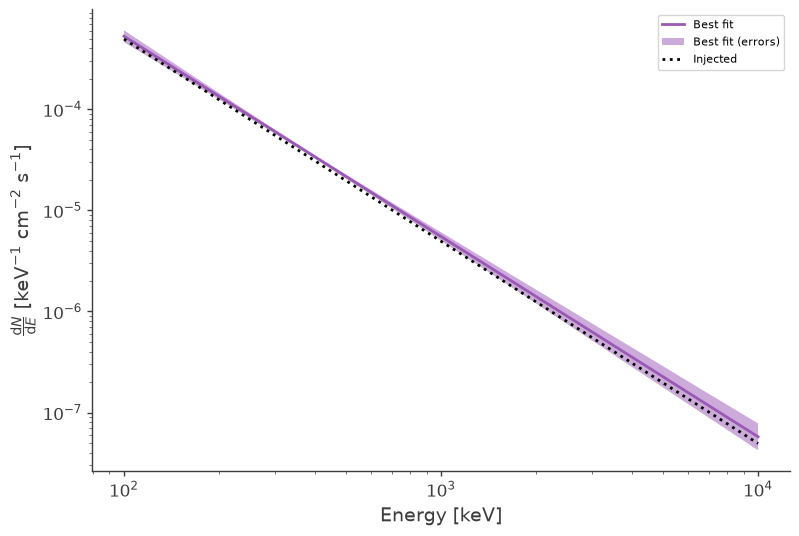

In [24]:
fig, ax = plt.subplots(figsize = (9, 6))

ax.plot(energy, flux_median, label = "Best fit")
ax.fill_between(energy, flux_lo, flux_hi, alpha = .5, label = "Best fit (errors)")
ax.plot(energy, flux_inj, color = 'black', ls = ":", label = "Injected")

ax.semilogx()
ax.semilogy()

ax.set_xlabel("Energy [keV]")
ax.set_ylabel(r"$\frac{\mathrm{d}N}{\mathrm{d}E}$ [keV$^{-1}$ cm$^{-2}$ s$^{-1}$]")

ax.legend();